# Terrain — Canopy Height, Hillshade & Exploratory Flood Inundation

**Library:** [`sitex`](../sitex) · **Original, fully-documented version:** [`02-ENV-DEM Terrain.ipynb`](../documentations/02-ENV-DEM%20Terrain.ipynb)

Thin, parameterized version of the DEM Terrain workflow. All the numeric logic —
Canopy Height Model, the hillshade gradient, the flood-fill algorithm and its true
per-pixel area — lives in `sitex.env.terrain_env`; this notebook is the parameters, the
calls that use them, and the plots.

**CHM = DSM − DTM.** DTM (NASADEM) is radar — it penetrates canopy to bare earth. DSM
(AW3D30) is optical stereo — it stops at the first solid surface (canopy, roofs).
Subtracting gives the height of everything above the ground; negative results after
grid alignment are sensor-noise/registration artefacts, not real height, and are
clipped to 0.

## 1. Install & import

In [1]:
# One-time setup, if `sitex` isn't already installed in this kernel:
# %pip install "sitex[env] @ git+https://github.com/ArchiColab/sitex.git"

import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
print("Running in:", "Google Colab" if IN_COLAB else "Local environment")

if IN_COLAB:
    %pip install "sitex[env] @ git+https://github.com/ArchiColab/sitex.git"

    # Input data (read-only) — downloaded fresh each session from the workshop's GitHub release
    DATA_RELEASE_URL = "https://github.com/ArchiColab/sitex/releases/download/workshop-data-v1/Colab_Outputs.zip"
    DATA_DIR = Path("/content/Colab_Outputs")
    if not DATA_DIR.exists():
        import urllib.request, zipfile
        zip_path = Path("/content/Colab_Outputs.zip")
        urllib.request.urlretrieve(DATA_RELEASE_URL, zip_path)
        with zipfile.ZipFile(zip_path) as zf:
            zf.extractall(DATA_DIR)

    # Your own results — saved to your own Google Drive so they persist across sessions
    from google.colab import drive
    drive.mount("/content/gdrive")
    OUTPUT_DIR = Path("/content/gdrive/MyDrive/SiteX_Outputs")
else:
    DATA_DIR = Path("..") / "data"
    OUTPUT_DIR = Path("..") / "outputs"

DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

import numpy as np

from sitex.core.config import CityConfig
from sitex.core.raster_viz import (
    add_caption,
    alpha_composite,
    colorize_array,
    hstack_images,
    mask_to_rgba,
    plot_raster_folium,
    render_map_panel,
    save_array_png,
    wgs84_bounds_for_folium,
)
from sitex.env import terrain_env as tenv

## 2. Site configuration & load DTM/DSM

In [2]:
city = CityConfig(
    place_name="Pleiku, Gia Lai, Vietnam",
    local_lat=13.9833,
    local_lon=108.0000,
    data_dir=DATA_DIR,
    output_dir=OUTPUT_DIR,
)

dtm, dsm = tenv.load_dtm_dsm_for_city(city)
print(f"DTM — shape: {dtm.shape}  CRS: {dtm.rio.crs}")
print(f"Elev: {float(dtm.min()):.1f} – {float(dtm.max()):.1f} m  (mean {float(dtm.mean()):.1f} m)")

DTM — shape: (245, 246)  CRS: EPSG:4326
Elev: 687.0 – 801.0 m  (mean 739.6 m)


## 3. Canopy Height Model (CHM)

CHM exported → ..\..\outputs\chm.tif
Min: 0.0 m  |  Max: 50.0 m  |  Mean: 3.1 m


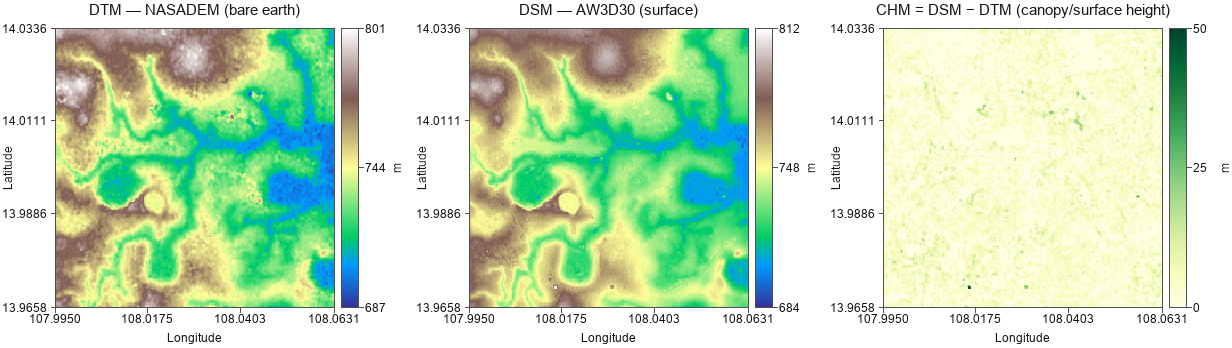

In [3]:
from IPython.display import Image, display

chm, dsm_matched = tenv.compute_chm(dtm, dsm)

chm_path = city.output_dir / "chm.tif"
chm.rio.to_raster(chm_path)
print(f"CHM exported → {chm_path}")
print(f"Min: {float(chm.min()):.1f} m  |  Max: {float(chm.max()):.1f} m  |  Mean: {float(chm.mean()):.1f} m")

# render_map_panel draws title + x/y coordinate ticks + a labelled colorbar via PIL
# only — the hand-built equivalent of xarray's `.plot()` on a matplotlib Axes, which
# would crash this kernel outright (see sitex.core.raster_viz's module docstring).
dtm_panel = render_map_panel(
    dtm.values, dtm.x.values, dtm.y.values, cmap_name="terrain",
    title="DTM — NASADEM (bare earth)", cbar_label="m",
    out_path=city.output_dir / "_dtm_panel.png",
)
dsm_panel = render_map_panel(
    dsm_matched.values, dsm_matched.x.values, dsm_matched.y.values, cmap_name="terrain",
    title="DSM — AW3D30 (surface)", cbar_label="m",
    out_path=city.output_dir / "_dsm_panel.png",
)
chm_panel = render_map_panel(
    chm.values, chm.x.values, chm.y.values, cmap_name="YlGn",
    title="CHM = DSM − DTM (canopy/surface height)", cbar_label="m",
    out_path=city.output_dir / "_chm_panel.png",
)

comparison_path = city.output_dir / "chm_comparison.png"
hstack_images([dtm_panel, dsm_panel, chm_panel], comparison_path)
display(Image(str(comparison_path)))

## 4. Hillshade

A cheap gradient-magnitude proxy, not a true sun-angle hillshade — good enough for a
quick terrain-roughness read without an extra library.

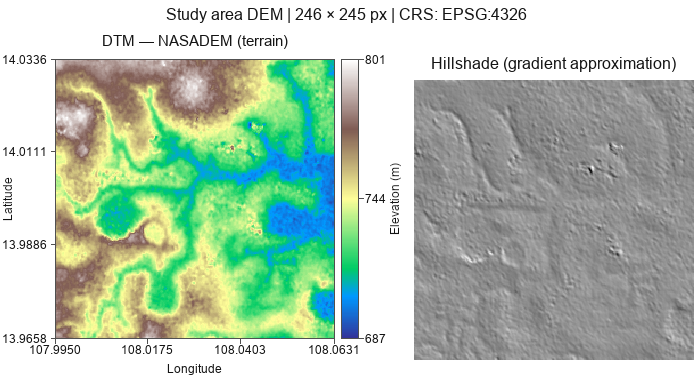

In [4]:
from PIL import Image as PILImage

shade = tenv.compute_hillshade_gradient(dtm)

shade_rgba = (np.repeat(shade[..., None], 4, axis=2) * 255).astype(np.uint8)
shade_rgba[..., 3] = 255
PANEL_SIZE = (280, 280)  # match render_map_panel's default plot area, so panels line up
shade_png = city.output_dir / "_shade.png"
PILImage.fromarray(shade_rgba, mode="RGBA").resize(PANEL_SIZE, PILImage.NEAREST).save(shade_png)

# Left panel: full axes (x/y coordinate ticks + colorbar), matching the original's
# `dtm.plot(...)` call. Right panel: title only, no axes — the original also turns
# axes off here (`axes[1].axis('off')`) since a unitless gradient has no elevation
# scale to show.
dtm_terrain_panel = render_map_panel(
    dtm.values, dtm.x.values, dtm.y.values, cmap_name="terrain",
    title="DTM — NASADEM (terrain)", cbar_label="Elevation (m)", plot_size=PANEL_SIZE,
    out_path=city.output_dir / "_dtm_terrain_panel.png",
)
shade_titled = add_caption(shade_png, "Hillshade (gradient approximation)", city.output_dir / "_shade_titled.png")

hillshade_path = city.output_dir / "dtm_hillshade.png"
hstack_images([dtm_terrain_panel, shade_titled], hillshade_path)
suptitle = f"Study area DEM  |  {dtm.shape[1]} × {dtm.shape[0]} px  |  CRS: {dtm.rio.crs}"
add_caption(hillshade_path, suptitle, hillshade_path)
display(Image(str(hillshade_path)))

## 5. Exploratory flood inundation (flood fill)

**Static, terrain-based model** — captures topographic depressions and connected
inundation extent; ignores flow velocity, infiltration, and time dynamics. Useful for
relative risk screening, not engineering flood routing.

The seed point is the lowest DTM cell — the most flood-prone starting point. Flood fill
keeps only cells *connected* to that seed at or below the water level, which is what
excludes an isolated low pixel elsewhere (e.g. a depression on a hilltop) that shares the
elevation but water could never physically reach.

In [5]:
import ipywidgets as widgets

seed_rc, seed_lat, seed_lon, elev_min = tenv.find_lowest_point(dtm)
area_m2 = tenv.pixel_area_m2(dtm, local_epsg=city.local_epsg)
print(f"Seed point: row={seed_rc[0]}, col={seed_rc[1]}  →  lat={seed_lat:.5f}, lon={seed_lon:.5f}  elev={elev_min} m")
print(f"Pixel size (EPSG:{city.local_epsg}): {area_m2:.1f} m²  (vs. assumed 900 m² at a flat 30x30)")

elevation = np.where(np.isnan(dtm.values), np.inf, dtm.values.astype(float))


def render_flood(water_level: float):
    """Pure function of `water_level` — the slider below calls this on every move."""
    mask = tenv.flood_fill(elevation, seed_rc, water_level)
    flooded_km2 = tenv.flood_extent_km2(mask, area_m2)

    terrain_rgba = colorize_array(dtm.values, "terrain", vmin=elev_min, vmax=elev_min + 30)
    flood_rgba = mask_to_rgba(mask, color=(0, 102, 255), alpha=160)
    composite = alpha_composite(terrain_rgba, flood_rgba)

    png_path = city.output_dir / f"flood_{int(water_level)}m.png"
    save_array_png(composite, png_path)
    #caption = f"Flood extent — water level {water_level:.0f} m  |  {flooded_km2:.3f} km² ({int(mask.sum())} px)"
    #add_caption(png_path, caption, png_path)
    return png_path


# ── Interactive slider — drag to test different flooding scenarios ───────────
WATER_LEVEL = elev_min + 5

water_slider = widgets.IntSlider(
    value=WATER_LEVEL,
    min=elev_min,
    max=elev_min + 30,
    step=1,
    description="Water (m):",
    continuous_update=False,
    style={"description_width": "initial"},
    layout=widgets.Layout(width="500px"),
)
flood_out = widgets.Output()


def update(change):
    png_path = render_flood(change["new"])
    with flood_out:
        flood_out.clear_output(wait=True)
        display(Image(str(png_path)))


water_slider.observe(update, names="value")
update({"new": WATER_LEVEL})
display(widgets.VBox([water_slider, flood_out]))

flood_png = city.output_dir / f"flood_{int(WATER_LEVEL)}m.png"

Seed point: row=57, col=171  →  lat=14.01778, lon=108.04250  elev=687 m
Pixel size (EPSG:32649): 924.1 m²  (vs. assumed 900 m² at a flat 30x30)



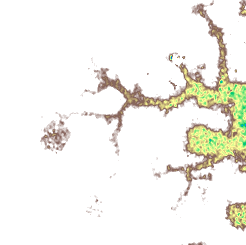

In [6]:
plot_raster_folium(
    flood_png,
    bounds=wgs84_bounds_for_folium(dtm),
    center=(seed_lat, seed_lon),
    name=f"Flood extent, {WATER_LEVEL:.0f} m",
)

---
## Notes

- **This is an exploratory, static model** — see the limitations table in the original
  notebook before treating any flood extent as an engineering-grade result.
- **Run `00-Data-Acquisition_RemoteSensing.ipynb` first** — this notebook fails fast
  (`FileNotFoundError`) if the DTM/DSM pair isn't already on disk under `data/dem/`.
- **Drag the `Water (m)` slider above** to test other flooding scenarios — `render_flood`
  is a pure function of `water_level`, called automatically on every slider move.
- **Plots here go through `sitex.core.raster_viz`, not matplotlib, on purpose.** This
  project's `gis` conda environment has a broken matplotlib rendering pipeline: building
  a `Figure` and never drawing it is fine, but any actual render — `plt.show()`,
  `fig.savefig()` (PNG *or even SVG*) — crashes the kernel outright, independent of what's
  plotted (confirmed with a bare `imshow` of random noise). This is the same category of
  fragility `POI_Accessibility.ipynb` already worked around for its own chart, and the
  `GeoDataFrame.plot()` crash found while migrating `01-ARCH-Building_Morphology.ipynb` —
  colormap-array + PIL + folium sidesteps it entirely, and `add_caption` (also PIL) stands
  in for matplotlib's `ax.set_title()`/`plt.suptitle()`.